# Input importance — leave-one-out retraining (full domain, 800×800)

Each physical input is removed (its *t* and *t−1* channels zeroed) and the full-domain
production model is **retrained from scratch** (300 epochs, no early stopping, same seed),
then compared to the baseline (`full_domain`, all inputs). This measures *irreplaceability*:
whether the remaining inputs can compensate. `(drop t-1)` zeroes the entire previous-hour
block; `height enc.` blanks the model's per-level height encoding.

Metrics: pooled RMSE (z0–11) and pattern correlation *r*, plus **per-layer** RMSE and *r*.
Part C cross-checks with a model-agnostic Random Forest fit directly on the data.
Data: `outputs/ablation_input/input_importance_layer.json`, `.../input_importance_800_retrain.json`.
Noise floor ≈ ±0.01 RMSE (full domain).

## Part A — overall importance (pooled RMSE and r)

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
D=json.load(open('../../outputs/ablation_input/input_importance_layer.json'))
ZH=[15,25,35,45,55,75,95,115,135,155,175,195]
LAB={'no_pm25bnd':'PM2.5 boundary','no_em':'emission','no_v':'v wind','no_u':'u wind',
     'no_qv':'qv','no_hour':'hour enc.','no_sp':'pressure','no_pt':'pt','no_height':'height enc.',
     't_only':'(drop t-1)'}
ORDER=['no_pm25bnd','no_em','no_v','no_u','no_qv','no_hour','no_sp','no_pt','no_height','t_only']
b=D['base']['pooled']
print(f'baseline (all inputs): RMSE {b["rmse"]:.3f}   r {b["r"]:.3f}\n')
print(f'{"input removed":>16} {"RMSE":>7} {"dRMSE":>8} {"%":>7} {"r":>7} {"dr":>8}')
print("-"*58)
for k in ORDER:
    m=D[k]['pooled']
    print(f'{LAB[k]:>16} {m["rmse"]:>7.3f} {m["rmse"]-b["rmse"]:>+8.3f} {100*(m["rmse"]-b["rmse"])/b["rmse"]:>+6.1f}% {m["r"]:>7.3f} {m["r"]-b["r"]:>+8.3f}')

baseline (all inputs): RMSE 0.755   r 0.887

   input removed    RMSE    dRMSE       %       r       dr
----------------------------------------------------------
  PM2.5 boundary   1.652   +0.896 +118.7%   0.867   -0.020
        emission   0.989   +0.234  +30.9%   0.854   -0.033
          v wind   0.927   +0.172  +22.7%   0.818   -0.069
          u wind   0.886   +0.131  +17.3%   0.839   -0.048
              qv   0.860   +0.104  +13.8%   0.872   -0.015
       hour enc.   0.822   +0.067   +8.8%   0.871   -0.016
        pressure   0.827   +0.071   +9.4%   0.887   -0.000
              pt   0.730   -0.026   -3.4%   0.876   -0.011
     height enc.   0.795   +0.040   +5.3%   0.882   -0.005
      (drop t-1)   0.802   +0.046   +6.1%   0.879   -0.008


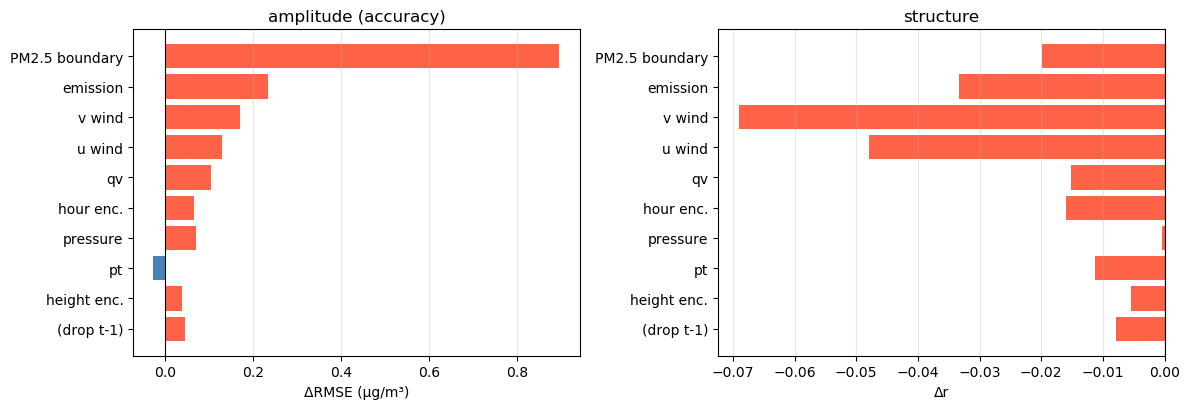

In [2]:
fig,axes=plt.subplots(1,2,figsize=(12,4.2))
names=[LAB[k] for k in ORDER]
dr=[D[k]['pooled']['rmse']-b['rmse'] for k in ORDER]
dp=[D[k]['pooled']['r']-b['r'] for k in ORDER]
axes[0].barh(names[::-1],dr[::-1],color=['tomato' if v>0 else 'steelblue' for v in dr[::-1]])
axes[0].set_xlabel('ΔRMSE (μg/m³)'); axes[0].set_title('amplitude (accuracy)')
axes[1].barh(names[::-1],dp[::-1],color=['tomato' if v<0 else 'steelblue' for v in dp[::-1]])
axes[1].set_xlabel('Δr'); axes[1].set_title('structure')
for ax in axes: ax.axvline(0,color='k',lw=0.8); ax.grid(True,alpha=0.3,axis='x')
plt.tight_layout(); plt.show()

## Part B — per-layer importance (where each input matters)

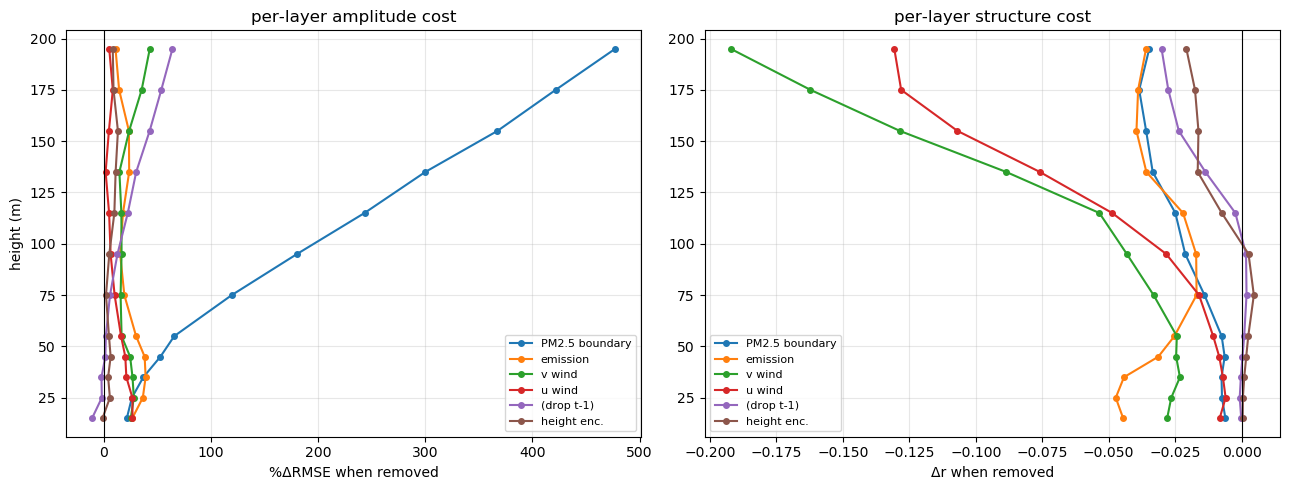

In [3]:
# per-layer ΔRMSE (% of baseline) and Δr, for the strongest inputs
SHOW=['no_pm25bnd','no_em','no_v','no_u','t_only','no_height']
fig,axes=plt.subplots(1,2,figsize=(13,5))
for k in SHOW:
    pdr=[100*(D[k]['layer'][str(z)]['rmse']-D['base']['layer'][str(z)]['rmse'])/D['base']['layer'][str(z)]['rmse'] for z in range(12)]
    dpp=[D[k]['layer'][str(z)]['r']-D['base']['layer'][str(z)]['r'] for z in range(12)]
    axes[0].plot(pdr,ZH,'o-',label=LAB[k],ms=4)
    axes[1].plot(dpp,ZH,'o-',label=LAB[k],ms=4)
axes[0].set_xlabel('%ΔRMSE when removed'); axes[0].set_ylabel('height (m)'); axes[0].set_title('per-layer amplitude cost')
axes[1].set_xlabel('Δr when removed'); axes[1].set_title('per-layer structure cost')
for ax in axes: ax.axvline(0,color='k',lw=0.8); ax.grid(True,alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [4]:
# full per-layer matrix — every input (cols) × every layer (rows)
SHORT={'no_pm25bnd':'bnd','no_em':'em','no_v':'v','no_u':'u','no_qv':'qv',
       'no_hour':'hour','no_sp':'sp','no_pt':'pt','no_height':'hgt','t_only':'t-1'}
def matrix(metric, title, fmt):
    print(title)
    print(f'{"h":>5} '+' '.join(f'{SHORT[k]:>6}' for k in ORDER))
    print('-'*(6+7*len(ORDER)))
    for z in range(12):
        bb=D['base']['layer'][str(z)][metric]
        cells=[]
        for k in ORDER:
            mm=D[k]['layer'][str(z)][metric]
            cells.append(fmt(mm,bb))
        print(f'{ZH[z]:>4}m '+' '.join(f'{c:>6}' for c in cells))
    print()
matrix('rmse','%ΔRMSE by layer (row) × input removed (col)  [positive = input helps]',
       lambda m,b: f'{100*(m-b)/b:+.0f}')
matrix('r','Δr×100 by layer (row) × input removed (col)  [negative = input helps structure]',
       lambda m,b: f'{100*(m-b):+.1f}')

%ΔRMSE by layer (row) × input removed (col)  [positive = input helps]
    h    bnd     em      v      u     qv   hour     sp     pt    hgt    t-1
----------------------------------------------------------------------------
  15m    +22    +27    +25    +27     +4     -2     -1    -13     -1    -11
  25m    +26    +36    +28    +27    +14     +7    +10     -4     +6     -2
  35m    +37    +39    +27    +21    +15     +7    +15     -4     +4     -2
  45m    +53    +38    +25    +20    +16     +9    +14     -2     +6     +1
  55m    +66    +30    +17    +16    +12     +9     +7     -3     +5     +2
  75m   +119    +19    +16    +10    +11     +8     +2     -4     +2     +6
  95m   +180    +15    +17     +6    +13    +10     +4     -2     +5    +13
 115m   +243    +18    +16     +5    +17    +12     +8     -1    +10    +22
 135m   +300    +24    +15     +2    +17    +15     +9     -2    +11    +30
 155m   +367    +23    +24     +5    +19    +20    +10     -0    +13    +43
 175m   +422    +

In [5]:
# per-layer table for one input at a time (edit KEY)
KEY='t_only'
print(f'{LAB[KEY]}  — per-layer (baseline vs removed)')
print(f'{"height":>7} {"RMSE_base":>9} {"RMSE_rm":>8} {"%dRMSE":>7} {"r_base":>7} {"r_rm":>6} {"dr":>7}')
print("-"*56)
for z in range(12):
    bb=D['base']['layer'][str(z)]; mm=D[KEY]['layer'][str(z)]
    print(f'{ZH[z]:>5}m {bb["rmse"]:>9.3f} {mm["rmse"]:>8.3f} {100*(mm["rmse"]-bb["rmse"])/bb["rmse"]:>+6.1f}% {bb["r"]:>7.3f} {mm["r"]:>6.3f} {mm["r"]-bb["r"]:>+7.3f}')

(drop t-1)  — per-layer (baseline vs removed)
 height RMSE_base  RMSE_rm  %dRMSE  r_base   r_rm      dr
--------------------------------------------------------
   15m     2.454    2.186  -10.9%   0.955  0.955  -0.000
   25m     2.086    2.049   -1.8%   0.947  0.946  -0.001
   35m     1.599    1.565   -2.1%   0.945  0.944  -0.000
   45m     1.267    1.286   +1.5%   0.940  0.941  +0.000
   55m     1.092    1.114   +2.0%   0.930  0.931  +0.001
   75m     0.753    0.797   +5.8%   0.889  0.891  +0.002
   95m     0.563    0.635  +12.8%   0.852  0.854  +0.002
  115m     0.446    0.546  +22.4%   0.829  0.827  -0.002
  135m     0.377    0.491  +30.3%   0.832  0.818  -0.014
  155m     0.320    0.457  +42.8%   0.841  0.817  -0.024
  175m     0.284    0.436  +53.7%   0.844  0.817  -0.028
  195m     0.260    0.427  +64.1%   0.839  0.808  -0.030


## Part C — Random Forest importance (model-agnostic cross-check)

RF fit directly on the data: features are the nine *t*-hour driver channels (per level,
z-scored), target the per-level-normalised log1p concentration. Impurity importance on
training days, fit quality on held-out test days.

RF R2: train 0.882  test 0.499


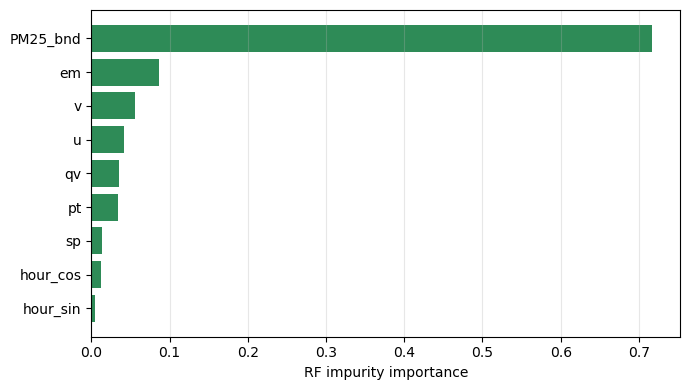

  PM25_bnd: 0.717
        em: 0.086
         v: 0.056
         u: 0.041
        qv: 0.036
        pt: 0.033
        sp: 0.013
  hour_cos: 0.013
  hour_sin: 0.005


In [6]:
import sys; sys.path.insert(0,'../../src')
import torch
from dataloader import PALMDatasetV2
from sklearn.ensemble import RandomForestRegressor
FEATS=['em','u','v','pt','qv','PM25_bnd','sp','hour_sin','hour_cos']; CH=[0,2,3,4,5,6,7,8,9]
test_h={'london_cm20190720-23':set(range(1,25)),'london_cm20190820-23':set(range(25,49)),'london_cm20190904-07':set(range(49,73))}
all_h={'london_cm20190720-23':set(range(1,97)),'london_cm20190820-23':set(range(1,97)),'london_cm20190904-07':set(range(1,145))}
train_h={s:all_h[s]-test_h[s] for s in all_h}
rng=np.random.RandomState(0)
def collect(hfilter,n_hours,n_pix):
    ds=PALMDatasetV2(normalise=True,roi=(0,200,400,600),hour_filter=hfilter,global_pm_norm=False,em_bg_norm=True,t_hist=1,z_range=(0,12))
    X=[];Y=[]
    for i in rng.choice(len(ds),size=min(n_hours,len(ds)),replace=False):
        x,y,mk=ds[i]; x=x.numpy(); y=y.numpy(); msk=mk.numpy().astype(bool)
        zz,yy,xx=np.where(msk); take=rng.choice(len(zz),size=min(n_pix,len(zz)),replace=False)
        X.append(x[CH][:,zz[take],yy[take],xx[take]].T); Y.append(y[zz[take],yy[take],xx[take]])
    return np.concatenate(X),np.concatenate(Y)
Xtr,Ytr=collect(train_h,60,3000); Xte,Yte=collect(test_h,40,2000)
rf=RandomForestRegressor(n_estimators=120,max_depth=18,min_samples_leaf=20,n_jobs=8,random_state=0).fit(Xtr,Ytr)
print(f'RF R2: train {rf.score(Xtr,Ytr):.3f}  test {rf.score(Xte,Yte):.3f}')
imp=rf.feature_importances_; order=np.argsort(imp)
fig,ax=plt.subplots(figsize=(7,4))
ax.barh([FEATS[i] for i in order],imp[order],color='seagreen'); ax.set_xlabel('RF impurity importance'); ax.grid(True,alpha=0.3,axis='x')
plt.tight_layout(); plt.show()
json.dump({'features':FEATS,'importance':imp.tolist(),'r2_test':float(rf.score(Xte,Yte))},open('../../outputs/ablation_input/rf_importance.json','w'),indent=1)
for i in order[::-1]: print(f'{FEATS[i]:>10}: {imp[i]:.3f}')